<a href="https://colab.research.google.com/github/freddy-7/TI3002C/blob/main/6_Regresi%C3%B3n_Lineal__Simple.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df = pd.read_csv("Analisis GAC Full7agosto 2026(Funnel).csv", header=None)
df.head(15)

,0,1,2,3,4,5,6,7,8,9,...,61,62,63,64,65,66,67,68,69,70
0,Funnel Historico por Mes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Funnel Enero 2025,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,GAC Angelopolis,NaN,NaN,NaN,NaN,NaN,NaN,Plaza Ange,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Item,Obj,Real,Acumulado,Obj al dia,Cumplimiento,NaN,Item,Obj,Real,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,Ventas,30,26,87%,30,87%,NaN,Ventas,4,2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,Leads generados,1282,1029,80%,1282,80%,NaN,Leads generados,120,110,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,Leads efectivos,766,710,93%,766,93%,NaN,Leads efectivos,111,99,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,Cita programada,180,189,105%,180,105%,NaN,Cita programada,24,41,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,Cita efectiva,150,109,73%,150,73%,NaN,Cita efectiva,20,28,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
df.shape

(264, 71)

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 264 entries, 0 to 263
Data columns (total 71 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       235 non-null    str    
 1   1       198 non-null    str    
 2   2       198 non-null    str    
 3   3       198 non-null    str    
 4   4       198 non-null    str    
 5   5       198 non-null    str    
 6   6       0 non-null      float64
 7   7       216 non-null    str    
 8   8       198 non-null    str    
 9   9       198 non-null    str    
 10  10      198 non-null    str    
 11  11      198 non-null    str    
 12  12      198 non-null    str    
 13  13      0 non-null      float64
 14  14      216 non-null    str    
 15  15      198 non-null    str    
 16  16      198 non-null    str    
 17  17      198 non-null    str    
 18  18      198 non-null    str    
 19  19      198 non-null    str    
 20  20      0 non-null      float64
 21  21      0 non-null      float64
 22  22      216 n

In [11]:
filas_meses = []

for i, valor in enumerate(df[0]):
    if pd.notna(valor):
        valor = str(valor).strip()

        if valor.startswith("Funnel ") and valor != "Funnel Historico por Mes":
            filas_meses.append(i)

filas_meses

[2,
 16,
 30,
 44,
 58,
 72,
 86,
 100,
 115,
 130,
 145,
 160,
 175,
 190,
 205,
 220,
 235,
 250]

In [12]:
for fila in filas_meses:
    print(fila, df.iloc[fila, 0])

2 Funnel Enero 2025
16 Funnel Febrero 2025
30 Funnel Marzo 2025
44 Funnel Abril 2025
58 Funnel Mayo 2025
72 Funnel Junio 2025
86 Funnel Julio 2025
100 Funnel Agosto 2025
115 Funnel Septiembre 2025
130 Funnel Octubre 2025
145 Funnel Noviembre 2025
160 Funnel Diciembre 2025
175 Funnel Enero 2026
190 Funnel Febrero 2026
205 Funnel Marzo 2026
220 Funnel Abril 2026
235 Funnel Mayo 2026
250 Funnel Junio 2026


In [13]:
for posicion, fila_mes in enumerate(filas_meses):

    # Nombre del mes
    mes = str(df.iloc[fila_mes, 0]).replace("Funnel ", "").strip()

    # Fin del bloque del mes
    if posicion + 1 < len(filas_meses):
        fin_mes = filas_meses[posicion + 1]
    else:
        fin_mes = len(df)

    # Buscar fila donde aparecen los encabezados "Item"
    fila_encabezado = None

    for fila in range(fila_mes + 1, min(fila_mes + 5, fin_mes)):

        cantidad_item = sum(
            str(valor).strip().lower() == "item"
            for valor in df.iloc[fila].dropna()
        )

        if cantidad_item >= 2:
            fila_encabezado = fila
            break

    print(mes, "-> fila encabezado:", fila_encabezado)

Enero 2025 -> fila encabezado: 4
Febrero 2025 -> fila encabezado: 18
Marzo 2025 -> fila encabezado: 32
Abril 2025 -> fila encabezado: 46
Mayo 2025 -> fila encabezado: 60
Junio 2025 -> fila encabezado: 74
Julio 2025 -> fila encabezado: 88
Agosto 2025 -> fila encabezado: 103
Septiembre 2025 -> fila encabezado: 118
Octubre 2025 -> fila encabezado: 133
Noviembre 2025 -> fila encabezado: 148
Diciembre 2025 -> fila encabezado: 163
Enero 2026 -> fila encabezado: 178
Febrero 2026 -> fila encabezado: 193
Marzo 2026 -> fila encabezado: 208
Abril 2026 -> fila encabezado: 223
Mayo 2026 -> fila encabezado: 238
Junio 2026 -> fila encabezado: 253


In [14]:
for posicion, fila_mes in enumerate(filas_meses):

    mes = str(df.iloc[fila_mes, 0]).replace("Funnel ", "").strip()

    if posicion + 1 < len(filas_meses):
        fin_mes = filas_meses[posicion + 1]
    else:
        fin_mes = len(df)

    # Buscar fila de encabezados
    fila_encabezado = None

    for fila in range(fila_mes + 1, min(fila_mes + 5, fin_mes)):

        cantidad_item = sum(
            str(valor).strip().lower() == "item"
            for valor in df.iloc[fila].dropna()
        )

        if cantidad_item >= 2:
            fila_encabezado = fila
            break

    fila_canales = fila_encabezado - 1

    canales = []

    for columna in range(df.shape[1]):

        if str(df.iloc[fila_encabezado, columna]).strip().lower() == "item":

            canal = df.iloc[fila_canales, columna]

            if pd.notna(canal):
                canales.append(str(canal).strip())

    print("\n", mes)
    print(canales)


 Enero 2025
['GAC Angelopolis', 'Plaza Ange', 'Piso', 'Digital', 'Galerias Tlaxcala', 'Otros', 'Plaza Moraledas']

 Febrero 2025
['GAC Angelopolis', 'Plaza Ange', 'Piso', 'Digital', 'Gran Patio', 'Otros', 'Estrategia de Prospeccion']

 Marzo 2025
['GAC Angelopolis', 'Plaza Ange', 'Piso', 'Digital', 'Gran Patio', 'Otros', 'Estrategia de Prospeccion']

 Abril 2025
['GAC Angelopolis', 'Plaza Ange', 'Piso', 'Digital', 'Gran Patio', 'Otros', 'Estrategia de Prospeccion']

 Mayo 2025
['GAC Angelopolis', 'Plaza Ange', 'Piso', 'Digital', 'Gran Patio', 'Otros', 'Estrategia de Prospeccion']

 Junio 2025
['GAC Angelopolis', 'Plaza Ange', 'Piso', 'Digital', 'Gran Patio', 'Otros', 'Estrategia de Prospeccion']

 Julio 2025
['GAC Angelopolis', 'Plaza Ange', 'Piso', 'Digital', 'Gran Patio', 'Otros', 'Estrategia de Prospeccion']

 Agosto 2025
['GAC Angelopolis', 'Plaza Ange', 'Piso', 'Digital', 'Galerias Tlaxcala', 'Otros', 'Estrategia de Prospeccion', 'Custom']

 Septiembre 2025
['GAC Angelopolis', 'P

In [15]:
registros = []

for posicion, fila_mes in enumerate(filas_meses):

    # Nombre del mes
    mes = str(df.iloc[fila_mes, 0]).replace("Funnel ", "").strip()

    # Determinar hasta dónde llega el bloque del mes
    if posicion + 1 < len(filas_meses):
        fin_mes = filas_meses[posicion + 1]
    else:
        fin_mes = len(df)

    # Buscar fila de encabezados
    fila_encabezado = None

    for fila in range(fila_mes + 1, min(fila_mes + 5, fin_mes)):

        cantidad_item = sum(
            str(valor).strip().lower() == "item"
            for valor in df.iloc[fila].dropna()
        )

        if cantidad_item >= 2:
            fila_encabezado = fila
            break

    fila_canales = fila_encabezado - 1

    # Buscar cada bloque que comienza con "Item"
    for columna in range(df.shape[1]):

        encabezado = str(
            df.iloc[fila_encabezado, columna]
        ).strip().lower()

        if encabezado == "item":

            canal = df.iloc[fila_canales, columna]

            if pd.isna(canal):
                continue

            canal = str(canal).strip()

            # Recorrer las filas del funnel
            for fila in range(fila_encabezado + 1, fin_mes):

                item = df.iloc[fila, columna]

                if pd.isna(item):
                    continue

                item = str(item).strip()

                if item == "":
                    continue

                # Obtener las variables del bloque
                obj = df.iloc[fila, columna + 1] if columna + 1 < df.shape[1] else np.nan
                real = df.iloc[fila, columna + 2] if columna + 2 < df.shape[1] else np.nan
                acumulado = df.iloc[fila, columna + 3] if columna + 3 < df.shape[1] else np.nan
                obj_al_dia = df.iloc[fila, columna + 4] if columna + 4 < df.shape[1] else np.nan
                cumplimiento = df.iloc[fila, columna + 5] if columna + 5 < df.shape[1] else np.nan

                registros.append([
                    mes,
                    canal,
                    item,
                    obj,
                    real,
                    acumulado,
                    obj_al_dia,
                    cumplimiento
                ])

In [16]:
df_funnel = pd.DataFrame(registros, columns=["Mes", "Canal", "Item", "Obj", "Real", "Acumulado", "Obj_al_dia", "Cumplimiento"])

In [17]:
df_funnel.head(20)

,Mes,Canal,Item,Obj,Real,Acumulado,Obj_al_dia,Cumplimiento
0,Enero 2025,GAC Angelopolis,Ventas,30,26,87%,30,87%
1,Enero 2025,GAC Angelopolis,Leads generados,1282,1029,80%,1282,80%
2,Enero 2025,GAC Angelopolis,Leads efectivos,766,710,93%,766,93%
3,Enero 2025,GAC Angelopolis,Cita programada,180,189,105%,180,105%
4,Enero 2025,GAC Angelopolis,Cita efectiva,150,109,73%,150,73%
5,Enero 2025,GAC Angelopolis,Prueba de manejo,102,86,84%,102,84%
6,Enero 2025,GAC Angelopolis,Solicitud de crédito generada,101,82,81%,101,81%
7,Enero 2025,GAC Angelopolis,Solicitud de crédito aprobada,48,29,60%,48,60%
8,Enero 2025,GAC Angelopolis,Cerrador,20,19,95%,20,95%
9,Enero 2025,GAC Angelopolis,Ventas,30,26,87%,30,87%


In [18]:
df_funnel.head(20)

,Mes,Canal,Item,Obj,Real,Acumulado,Obj_al_dia,Cumplimiento
0,Enero 2025,GAC Angelopolis,Ventas,30,26,87%,30,87%
1,Enero 2025,GAC Angelopolis,Leads generados,1282,1029,80%,1282,80%
2,Enero 2025,GAC Angelopolis,Leads efectivos,766,710,93%,766,93%
3,Enero 2025,GAC Angelopolis,Cita programada,180,189,105%,180,105%
4,Enero 2025,GAC Angelopolis,Cita efectiva,150,109,73%,150,73%
5,Enero 2025,GAC Angelopolis,Prueba de manejo,102,86,84%,102,84%
6,Enero 2025,GAC Angelopolis,Solicitud de crédito generada,101,82,81%,101,81%
7,Enero 2025,GAC Angelopolis,Solicitud de crédito aprobada,48,29,60%,48,60%
8,Enero 2025,GAC Angelopolis,Cerrador,20,19,95%,20,95%
9,Enero 2025,GAC Angelopolis,Ventas,30,26,87%,30,87%


In [19]:
df_funnel.shape

(1340, 8)

In [20]:
df_funnel.shape

(1340, 8)

In [21]:
df_funnel[(df_funnel["Mes"] == "Junio 2026") & (df_funnel["Canal"] == "Plaza Pachuca")]

,Mes,Canal,Item,Obj,Real,Acumulado,Obj_al_dia,Cumplimiento
1320,Junio 2026,Plaza Pachuca,Ventas,2,4,110%,2,110%
1321,Junio 2026,Plaza Pachuca,Leads generados,60,43,72%,60,72%
1322,Junio 2026,Plaza Pachuca,Leads efectivos,45,43,96%,45,96%
1323,Junio 2026,Plaza Pachuca,Cita programada,28,14,50%,28,50%
1324,Junio 2026,Plaza Pachuca,Cita efectiva,20,12,60%,20,60%
1325,Junio 2026,Plaza Pachuca,Prueba de manejo,12,6,50%,12,50%
1326,Junio 2026,Plaza Pachuca,Solicitud de crédito generada,5,6,110%,5,110%
1327,Junio 2026,Plaza Pachuca,Solicitud de crédito aprobada,3,3,100%,3,100%
1328,Junio 2026,Plaza Pachuca,Formalizado,1,0,0%,1,0%
1329,Junio 2026,Plaza Pachuca,Ventas,2,4,110%,2,110%


In [22]:
df_funnel["Item"].value_counts()

Item
Ventas                           268
Leads generados                  134
Leads efectivos                  134
Cita programada                  134
Cita efectiva                    134
Prueba de manejo                 134
Solicitud de crédito generada    134
Solicitud de crédito aprobada    134
Formalizado                      127
Cerrador                           7
Name: count, dtype: int64

In [23]:
df_funnel.head(20)
df_funnel.shape
df_funnel.info()
df_funnel["Item"].value_counts()

<class 'pandas.DataFrame'>
RangeIndex: 1340 entries, 0 to 1339
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   Mes           1340 non-null   str  
 1   Canal         1340 non-null   str  
 2   Item          1340 non-null   str  
 3   Obj           1320 non-null   str  
 4   Real          1329 non-null   str  
 5   Acumulado     1320 non-null   str  
 6   Obj_al_dia    1320 non-null   str  
 7   Cumplimiento  1320 non-null   str  
dtypes: str(8)
memory usage: 83.9 KB


Item
Ventas                           268
Leads generados                  134
Leads efectivos                  134
Cita programada                  134
Cita efectiva                    134
Prueba de manejo                 134
Solicitud de crédito generada    134
Solicitud de crédito aprobada    134
Formalizado                      127
Cerrador                           7
Name: count, dtype: int64

In [24]:
#Eliminar duplicados exactos
df_funnel = df_funnel.drop_duplicates().reset_index(drop=True)

In [25]:
df_funnel.isnull().sum()

Mes              0
Canal            0
Item             0
Obj             18
Real            10
Acumulado       18
Obj_al_dia      18
Cumplimiento    18
dtype: int64

In [26]:
df_funnel.info()

<class 'pandas.DataFrame'>
RangeIndex: 1210 entries, 0 to 1209
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   Mes           1210 non-null   str  
 1   Canal         1210 non-null   str  
 2   Item          1210 non-null   str  
 3   Obj           1192 non-null   str  
 4   Real          1200 non-null   str  
 5   Acumulado     1192 non-null   str  
 6   Obj_al_dia    1192 non-null   str  
 7   Cumplimiento  1192 non-null   str  
dtypes: str(8)
memory usage: 75.8 KB


In [ ]:
df_funnel[df_funnel.isnull().any(axis=1)]

,Mes,Canal,Item,Obj,Real,Acumulado,Obj_al_dia,Cumplimiento
55,Enero 2025,Plaza Moraledas,Ventas,3,NaN,0%,3,0%
581,Septiembre 2025,Custom,Ventas,NaN,NaN,NaN,NaN,NaN
582,Septiembre 2025,Custom,Leads generados,NaN,NaN,NaN,NaN,NaN
583,Septiembre 2025,Custom,Leads efectivos,NaN,NaN,NaN,NaN,NaN
584,Septiembre 2025,Custom,Cita programada,NaN,NaN,NaN,NaN,NaN
585,Septiembre 2025,Custom,Cita efectiva,NaN,NaN,NaN,NaN,NaN
586,Septiembre 2025,Custom,Prueba de manejo,NaN,NaN,NaN,NaN,NaN
587,Septiembre 2025,Custom,Solicitud de crédito generada,NaN,NaN,NaN,NaN,NaN
588,Septiembre 2025,Custom,Solicitud de crédito aprobada,NaN,NaN,NaN,NaN,NaN
589,Septiembre 2025,Custom,Formalizado,NaN,NaN,NaN,NaN,NaN


In [ ]:
df_funnel[df_funnel["Obj"].isnull()][["Mes", "Canal", "Item", "Obj", "Real", "Acumulado", "Obj_al_dia", "Cumplimiento"]]

,Mes,Canal,Item,Obj,Real,Acumulado,Obj_al_dia,Cumplimiento
581,Septiembre 2025,Custom,Ventas,NaN,NaN,NaN,NaN,NaN
582,Septiembre 2025,Custom,Leads generados,NaN,NaN,NaN,NaN,NaN
583,Septiembre 2025,Custom,Leads efectivos,NaN,NaN,NaN,NaN,NaN
584,Septiembre 2025,Custom,Cita programada,NaN,NaN,NaN,NaN,NaN
585,Septiembre 2025,Custom,Cita efectiva,NaN,NaN,NaN,NaN,NaN
586,Septiembre 2025,Custom,Prueba de manejo,NaN,NaN,NaN,NaN,NaN
587,Septiembre 2025,Custom,Solicitud de crédito generada,NaN,NaN,NaN,NaN,NaN
588,Septiembre 2025,Custom,Solicitud de crédito aprobada,NaN,NaN,NaN,NaN,NaN
589,Septiembre 2025,Custom,Formalizado,NaN,NaN,NaN,NaN,NaN
941,Marzo 2026,Otros,Ventas,NaN,17,NaN,NaN,NaN


In [ ]:
df_funnel[df_funnel["Real"].isnull()][["Mes", "Canal", "Item", "Obj", "Real", "Acumulado", "Obj_al_dia", "Cumplimiento"]]

,Mes,Canal,Item,Obj,Real,Acumulado,Obj_al_dia,Cumplimiento
55,Enero 2025,Plaza Moraledas,Ventas,3,NaN,0%,3,0%
581,Septiembre 2025,Custom,Ventas,NaN,NaN,NaN,NaN,NaN
582,Septiembre 2025,Custom,Leads generados,NaN,NaN,NaN,NaN,NaN
583,Septiembre 2025,Custom,Leads efectivos,NaN,NaN,NaN,NaN,NaN
584,Septiembre 2025,Custom,Cita programada,NaN,NaN,NaN,NaN,NaN
585,Septiembre 2025,Custom,Cita efectiva,NaN,NaN,NaN,NaN,NaN
586,Septiembre 2025,Custom,Prueba de manejo,NaN,NaN,NaN,NaN,NaN
587,Septiembre 2025,Custom,Solicitud de crédito generada,NaN,NaN,NaN,NaN,NaN
588,Septiembre 2025,Custom,Solicitud de crédito aprobada,NaN,NaN,NaN,NaN,NaN
589,Septiembre 2025,Custom,Formalizado,NaN,NaN,NaN,NaN,NaN


In [ ]:
df_funnel[(df_funnel["Mes"] == "Enero 2025") & (df_funnel["Item"] == "Ventas")][["Canal", "Real", "Cumplimiento"]]

,Canal,Real,Cumplimiento
0,GAC Angelopolis,26,87%
9,Plaza Ange,2,50%
18,Piso,10,71%
27,Piso,10,67%
28,Digital,9,110%
37,Galerias Tlaxcala,3,75%
46,Otros,2,110%
55,Plaza Moraledas,NaN,0%
64,Plaza Moraledas,0,0%


In [34]:
df_funnel["Mes"] = df_funnel["Mes"].astype(str).str.strip()
df_funnel["Canal"] = df_funnel["Canal"].astype(str).str.strip()
df_funnel["Item"] = df_funnel["Item"].astype(str).str.strip()

In [ ]:
df_funnel.loc[(df_funnel["Mes"] == "Enero 2025") & (df_funnel["Canal"] == "Plaza Moraledas") & (df_funnel["Item"] == "Ventas"), "Real"] = "0"

In [38]:
columnas_numericas = ["Obj","Real","Acumulado","Obj_al_dia","Cumplimiento"]

df_funnel = df_funnel.dropna(subset=columnas_numericas, how="all").reset_index(drop=True)

In [37]:
df_funnel.isnull().sum()

Mes             0
Canal           0
Item            0
Obj             9
Real            0
Acumulado       9
Obj_al_dia      9
Cumplimiento    9
dtype: int64

Tratamiento de valores nulos: Se identificaron diferentes tipos de valores faltantes. Los registros completamente vacíos correspondientes a bloques sin información fueron eliminados. Los valores faltantes que conservaban información en otras variables se mantuvieron para evitar la pérdida de observaciones útiles. Únicamente se sustituyó por cero un valor faltante de ventas cuando los indicadores de cumplimiento registrados en la base confirmaban un resultado de 0%.

In [39]:
df_funnel["Obj"] = pd.to_numeric(df_funnel["Obj"],errors="coerce")

df_funnel["Real"] = pd.to_numeric(df_funnel["Real"], errors="coerce")

df_funnel["Obj_al_dia"] = pd.to_numeric(df_funnel["Obj_al_dia"],errors="coerce")

In [40]:
df_funnel["Acumulado"] = (df_funnel["Acumulado"].str.replace("%", "", regex=False))

df_funnel["Cumplimiento"] = (df_funnel["Cumplimiento"].str.replace("%", "", regex=False))

In [41]:
df_funnel["Acumulado"] = pd.to_numeric(df_funnel["Acumulado"],errors="coerce")

df_funnel["Cumplimiento"] = pd.to_numeric(df_funnel["Cumplimiento"], errors="coerce")

In [42]:
df_funnel.info()

<class 'pandas.DataFrame'>
RangeIndex: 1201 entries, 0 to 1200
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Mes           1201 non-null   str    
 1   Canal         1201 non-null   str    
 2   Item          1201 non-null   str    
 3   Obj           1191 non-null   float64
 4   Real          1200 non-null   float64
 5   Acumulado     1192 non-null   float64
 6   Obj_al_dia    1190 non-null   float64
 7   Cumplimiento  1192 non-null   float64
dtypes: float64(5), str(3)
memory usage: 75.2 KB


In [43]:
df_funnel.head()

,Mes,Canal,Item,Obj,Real,Acumulado,Obj_al_dia,Cumplimiento
0,Enero 2025,GAC Angelopolis,Ventas,30.0,26.0,87.0,30.0,87.0
1,Enero 2025,GAC Angelopolis,Leads generados,1282.0,1029.0,80.0,1282.0,80.0
2,Enero 2025,GAC Angelopolis,Leads efectivos,766.0,710.0,93.0,766.0,93.0
3,Enero 2025,GAC Angelopolis,Cita programada,180.0,189.0,105.0,180.0,105.0
4,Enero 2025,GAC Angelopolis,Cita efectiva,150.0,109.0,73.0,150.0,73.0


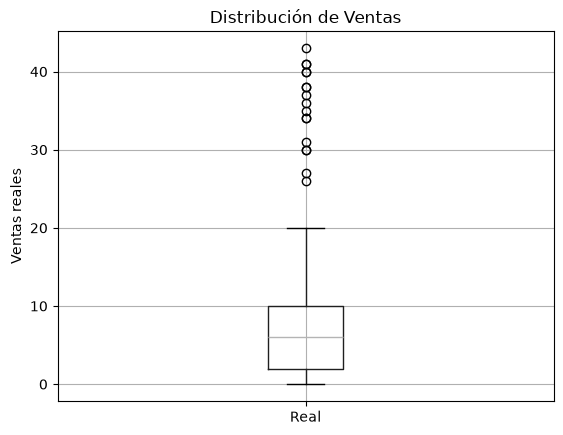

In [44]:
df_funnel[df_funnel["Item"] == "Ventas"].boxplot(column="Real")

plt.title("Distribución de Ventas")
plt.ylabel("Ventas reales")
plt.show()

In [45]:
ventas = df_funnel[df_funnel["Item"] == "Ventas"]["Real"]

Q1 = ventas.quantile(0.25)
Q3 = ventas.quantile(0.75)

IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

outliers_ventas = df_funnel[(df_funnel["Item"] == "Ventas") & ((df_funnel["Real"] < limite_inferior) |(df_funnel["Real"] > limite_superior))]

outliers_ventas

,Mes,Canal,Item,Obj,Real,Acumulado,Obj_al_dia,Cumplimiento
0,Enero 2025,GAC Angelopolis,Ventas,30.0,26.0,87.0,30.0,87.0
130,Marzo 2025,GAC Angelopolis,Ventas,30.0,30.0,100.0,30.0,100.0
194,Abril 2025,GAC Angelopolis,Ventas,30.0,30.0,100.0,30.0,100.0
257,Mayo 2025,GAC Angelopolis,Ventas,41.0,34.0,83.0,41.0,83.0
320,Junio 2025,GAC Angelopolis,Ventas,40.0,40.0,100.0,40.0,100.0
383,Julio 2025,GAC Angelopolis,Ventas,45.0,36.0,80.0,45.0,80.0
446,Agosto 2025,GAC Angelopolis,Ventas,45.0,27.0,60.0,45.0,60.0
518,Septiembre 2025,GAC Angelopolis,Ventas,45.0,38.0,84.0,45.0,84.0
581,Octubre 2025,GAC Angelopolis,Ventas,45.0,40.0,89.0,45.0,89.0
644,Noviembre 2025,GAC Angelopolis,Ventas,45.0,43.0,96.0,45.0,96.0


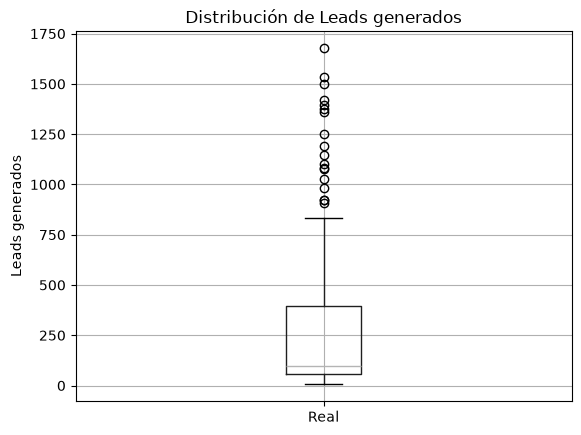

In [46]:
df_funnel[df_funnel["Item"] == "Leads generados"].boxplot(column="Real")

plt.title("Distribución de Leads generados")
plt.ylabel("Leads generados")
plt.show()

In [47]:
ventas = df_funnel[df_funnel["Item"] == "Leads generados"]["Real"]

Q1 = ventas.quantile(0.25)
Q3 = ventas.quantile(0.75)

IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

outliers_ventas = df_funnel[(df_funnel["Item"] == "Leads generados") & ((df_funnel["Real"] < limite_inferior) |(df_funnel["Real"] > limite_superior))]

outliers_ventas

,Mes,Canal,Item,Obj,Real,Acumulado,Obj_al_dia,Cumplimiento
1,Enero 2025,GAC Angelopolis,Leads generados,1282.0,1029.0,80.0,1282.0,80.0
131,Marzo 2025,GAC Angelopolis,Leads generados,757.0,925.0,110.0,757.0,110.0
195,Abril 2025,GAC Angelopolis,Leads generados,757.0,1149.0,110.0,757.0,110.0
321,Junio 2025,GAC Angelopolis,Leads generados,970.0,1083.0,110.0,970.0,110.0
384,Julio 2025,GAC Angelopolis,Leads generados,1050.0,1358.0,110.0,1050.0,110.0
447,Agosto 2025,GAC Angelopolis,Leads generados,1050.0,1419.0,135.0,1050.0,135.0
519,Septiembre 2025,GAC Angelopolis,Leads generados,1050.0,1100.0,105.0,1050.0,105.0
582,Octubre 2025,GAC Angelopolis,Leads generados,1050.0,1192.0,114.0,1050.0,114.0
645,Noviembre 2025,GAC Angelopolis,Leads generados,1125.0,1075.0,96.0,1125.0,96.0
708,Diciembre 2025,GAC Angelopolis,Leads generados,1280.0,1534.0,110.0,1280.0,110.0


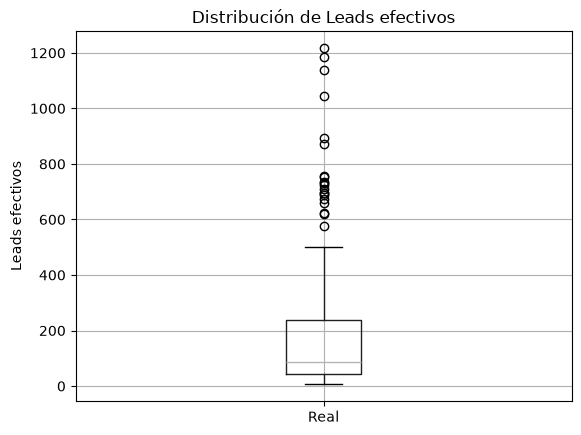

In [48]:
df_funnel[df_funnel["Item"] == "Leads efectivos"].boxplot(column="Real")

plt.title("Distribución de Leads efectivos")
plt.ylabel("Leads efectivos")
plt.show()

In [49]:
ventas = df_funnel[df_funnel["Item"] == "Leads efectivos"]["Real"]

Q1 = ventas.quantile(0.25)
Q3 = ventas.quantile(0.75)

IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

outliers_ventas = df_funnel[(df_funnel["Item"] == "Leads efectivos") & ((df_funnel["Real"] < limite_inferior) |(df_funnel["Real"] > limite_superior))]

outliers_ventas

,Mes,Canal,Item,Obj,Real,Acumulado,Obj_al_dia,Cumplimiento
2,Enero 2025,GAC Angelopolis,Leads efectivos,766.0,710.0,93.0,766.0,93.0
132,Marzo 2025,GAC Angelopolis,Leads efectivos,501.0,731.0,110.0,501.0,110.0
196,Abril 2025,GAC Angelopolis,Leads efectivos,501.0,873.0,110.0,501.0,110.0
259,Mayo 2025,GAC Angelopolis,Leads efectivos,789.0,689.0,87.0,789.0,87.0
322,Junio 2025,GAC Angelopolis,Leads efectivos,789.0,694.0,88.0,789.0,88.0
385,Julio 2025,GAC Angelopolis,Leads efectivos,750.0,893.0,110.0,750.0,110.0
448,Agosto 2025,GAC Angelopolis,Leads efectivos,750.0,624.0,83.0,750.0,83.0
520,Septiembre 2025,GAC Angelopolis,Leads efectivos,750.0,660.0,88.0,750.0,88.0
583,Octubre 2025,GAC Angelopolis,Leads efectivos,750.0,695.0,93.0,750.0,93.0
646,Noviembre 2025,GAC Angelopolis,Leads efectivos,785.0,758.0,97.0,785.0,97.0


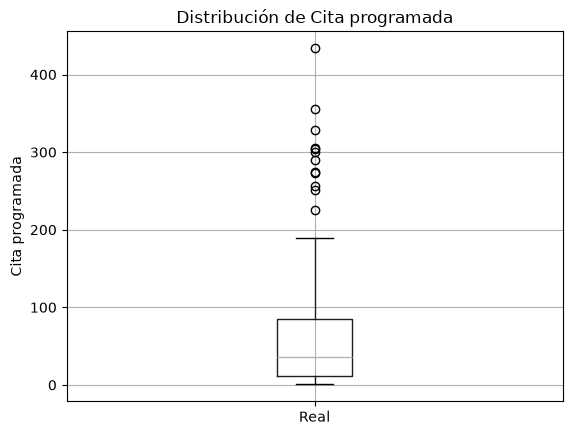

In [50]:
df_funnel[df_funnel["Item"] == "Cita programada"].boxplot(column="Real")

plt.title("Distribución de Cita programada")
plt.ylabel("Cita programada")
plt.show()

In [51]:
ventas = df_funnel[df_funnel["Item"] == "Cita programada"]["Real"]

Q1 = ventas.quantile(0.25)
Q3 = ventas.quantile(0.75)

IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

outliers_ventas = df_funnel[(df_funnel["Item"] == "Cita programada") & ((df_funnel["Real"] < limite_inferior) |(df_funnel["Real"] > limite_superior))]

outliers_ventas

,Mes,Canal,Item,Obj,Real,Acumulado,Obj_al_dia,Cumplimiento
323,Junio 2025,GAC Angelopolis,Cita programada,214.0,226.0,106.0,214.0,106.0
386,Julio 2025,GAC Angelopolis,Cita programada,230.0,256.0,110.0,230.0,110.0
449,Agosto 2025,GAC Angelopolis,Cita programada,230.0,300.0,130.0,230.0,130.0
521,Septiembre 2025,GAC Angelopolis,Cita programada,230.0,273.0,119.0,230.0,119.0
584,Octubre 2025,GAC Angelopolis,Cita programada,230.0,304.0,132.0,230.0,132.0
647,Noviembre 2025,GAC Angelopolis,Cita programada,240.0,329.0,110.0,240.0,110.0
710,Diciembre 2025,GAC Angelopolis,Cita programada,280.0,290.0,104.0,280.0,104.0
764,Enero 2026,GAC Angelopolis,Cita programada,280.0,274.0,98.0,280.0,98.0
827,Febrero 2026,GAC Angelopolis,Cita programada,285.0,434.0,110.0,285.0,110.0
890,Marzo 2026,GAC Angelopolis,Cita programada,285.0,305.0,107.0,285.0,107.0


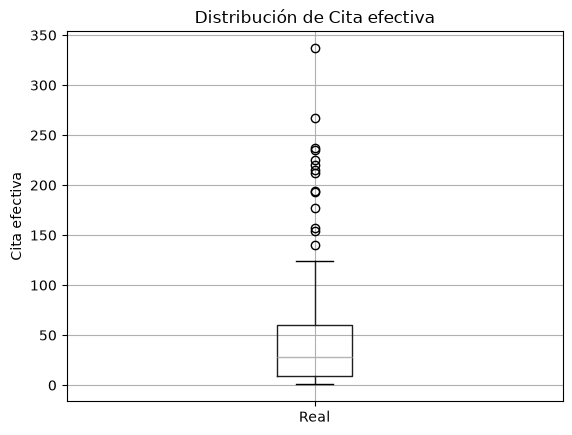

In [52]:
df_funnel[df_funnel["Item"] == "Cita efectiva"].boxplot(column="Real")

plt.title("Distribución de Cita efectiva")
plt.ylabel("Cita efectiva")
plt.show()

In [53]:
ventas = df_funnel[df_funnel["Item"] == "Cita efectiva"]["Real"]

Q1 = ventas.quantile(0.25)
Q3 = ventas.quantile(0.75)

IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

outliers_ventas = df_funnel[(df_funnel["Item"] == "Cita efectiva") & ((df_funnel["Real"] < limite_inferior) |(df_funnel["Real"] > limite_superior))]

outliers_ventas

,Mes,Canal,Item,Obj,Real,Acumulado,Obj_al_dia,Cumplimiento
134,Marzo 2025,GAC Angelopolis,Cita efectiva,149.0,140.0,94.0,149.0,94.0
261,Mayo 2025,GAC Angelopolis,Cita efectiva,160.0,157.0,98.0,160.0,98.0
324,Junio 2025,GAC Angelopolis,Cita efectiva,160.0,177.0,110.0,160.0,110.0
387,Julio 2025,GAC Angelopolis,Cita efectiva,185.0,193.0,104.0,185.0,104.0
450,Agosto 2025,GAC Angelopolis,Cita efectiva,206.0,194.0,94.0,206.0,94.0
522,Septiembre 2025,GAC Angelopolis,Cita efectiva,206.0,212.0,103.0,206.0,103.0
585,Octubre 2025,GAC Angelopolis,Cita efectiva,206.0,220.0,107.0,206.0,107.0
648,Noviembre 2025,GAC Angelopolis,Cita efectiva,215.0,225.0,105.0,215.0,105.0
711,Diciembre 2025,GAC Angelopolis,Cita efectiva,215.0,235.0,109.0,215.0,109.0
765,Enero 2026,GAC Angelopolis,Cita efectiva,215.0,215.0,100.0,215.0,100.0


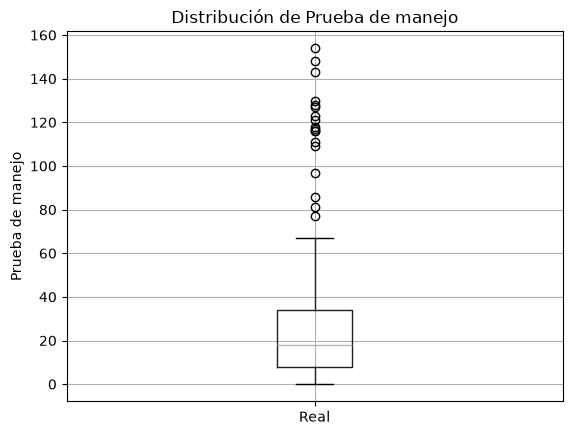

In [54]:
df_funnel[df_funnel["Item"] == "Prueba de manejo"].boxplot(column="Real")

plt.title("Distribución de Prueba de manejo")
plt.ylabel("Prueba de manejo")
plt.show()

In [58]:
ventas = df_funnel[df_funnel["Item"] == "Prueba de manejo"]["Real"]

Q1 = ventas.quantile(0.25)
Q3 = ventas.quantile(0.75)

IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

outliers_ventas = df_funnel[(df_funnel["Item"] == "Prueba de manejo") & ((df_funnel["Real"] < limite_inferior) |(df_funnel["Real"] > limite_superior))]

outliers_ventas

,Mes,Canal,Item,Obj,Real,Acumulado,Obj_al_dia,Cumplimiento
5,Enero 2025,GAC Angelopolis,Prueba de manejo,102.0,86.0,84.0,102.0,84.0
70,Febrero 2025,GAC Angelopolis,Prueba de manejo,103.0,97.0,94.0,62.0,110.0
135,Marzo 2025,GAC Angelopolis,Prueba de manejo,103.0,77.0,75.0,103.0,75.0
199,Abril 2025,GAC Angelopolis,Prueba de manejo,100.0,81.0,81.0,100.0,81.0
262,Mayo 2025,GAC Angelopolis,Prueba de manejo,100.0,121.0,110.0,100.0,110.0
325,Junio 2025,GAC Angelopolis,Prueba de manejo,100.0,111.0,110.0,100.0,110.0
388,Julio 2025,GAC Angelopolis,Prueba de manejo,110.0,127.0,110.0,110.0,110.0
451,Agosto 2025,GAC Angelopolis,Prueba de manejo,126.0,123.0,98.0,126.0,98.0
523,Septiembre 2025,GAC Angelopolis,Prueba de manejo,126.0,116.0,92.0,126.0,92.0
586,Octubre 2025,GAC Angelopolis,Prueba de manejo,126.0,154.0,122.0,126.0,122.0


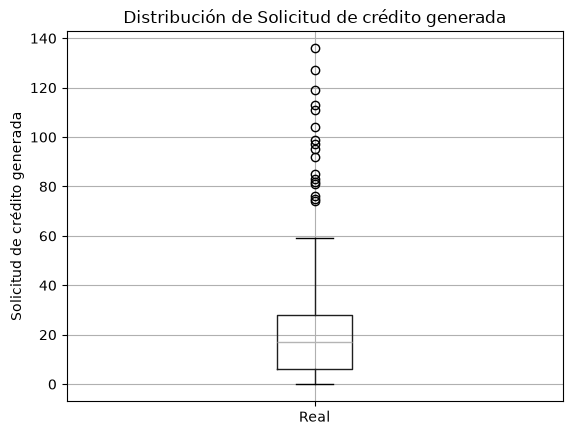

In [55]:
df_funnel[df_funnel["Item"] == "Solicitud de crédito generada"].boxplot(column="Real")

plt.title("Distribución de Solicitud de crédito generada")
plt.ylabel("Solicitud de crédito generada")
plt.show()

In [59]:
ventas = df_funnel[df_funnel["Item"] == "Solicitud de crédito generada"]["Real"]

Q1 = ventas.quantile(0.25)
Q3 = ventas.quantile(0.75)

IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

outliers_ventas = df_funnel[(df_funnel["Item"] == "Solicitud de crédito generada") & ((df_funnel["Real"] < limite_inferior) |(df_funnel["Real"] > limite_superior))]

outliers_ventas

,Mes,Canal,Item,Obj,Real,Acumulado,Obj_al_dia,Cumplimiento
6,Enero 2025,GAC Angelopolis,Solicitud de crédito generada,101.0,82.0,81.0,101.0,81.0
71,Febrero 2025,GAC Angelopolis,Solicitud de crédito generada,92.0,75.0,82.0,55.0,110.0
136,Marzo 2025,GAC Angelopolis,Solicitud de crédito generada,92.0,92.0,100.0,92.0,100.0
263,Mayo 2025,GAC Angelopolis,Solicitud de crédito generada,70.0,76.0,109.0,70.0,109.0
326,Junio 2025,GAC Angelopolis,Solicitud de crédito generada,90.0,97.0,108.0,90.0,108.0
389,Julio 2025,GAC Angelopolis,Solicitud de crédito generada,100.0,104.0,104.0,100.0,104.0
452,Agosto 2025,GAC Angelopolis,Solicitud de crédito generada,115.0,99.0,86.0,115.0,86.0
524,Septiembre 2025,GAC Angelopolis,Solicitud de crédito generada,115.0,127.0,110.0,115.0,110.0
587,Octubre 2025,GAC Angelopolis,Solicitud de crédito generada,115.0,136.0,118.0,115.0,118.0
650,Noviembre 2025,GAC Angelopolis,Solicitud de crédito generada,125.0,119.0,95.0,125.0,95.0


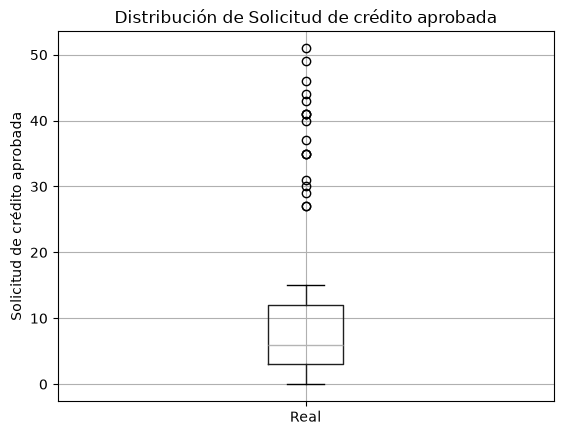

In [56]:
df_funnel[df_funnel["Item"] == "Solicitud de crédito aprobada"].boxplot(column="Real")

plt.title("Distribución de Solicitud de crédito aprobada")
plt.ylabel("Solicitud de crédito aprobada")
plt.show()

In [60]:
ventas = df_funnel[df_funnel["Item"] == "Solicitud de crédito aprobada"]["Real"]

Q1 = ventas.quantile(0.25)
Q3 = ventas.quantile(0.75)

IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

outliers_ventas = df_funnel[(df_funnel["Item"] == "Solicitud de crédito aprobada") & ((df_funnel["Real"] < limite_inferior) |(df_funnel["Real"] > limite_superior))]

outliers_ventas

,Mes,Canal,Item,Obj,Real,Acumulado,Obj_al_dia,Cumplimiento
7,Enero 2025,GAC Angelopolis,Solicitud de crédito aprobada,48.0,29.0,60.0,48.0,60.0
72,Febrero 2025,GAC Angelopolis,Solicitud de crédito aprobada,46.0,27.0,59.0,27.0,99.0
137,Marzo 2025,GAC Angelopolis,Solicitud de crédito aprobada,46.0,30.0,65.0,46.0,65.0
201,Abril 2025,GAC Angelopolis,Solicitud de crédito aprobada,46.0,35.0,76.0,46.0,76.0
264,Mayo 2025,GAC Angelopolis,Solicitud de crédito aprobada,42.0,40.0,95.0,42.0,95.0
327,Junio 2025,GAC Angelopolis,Solicitud de crédito aprobada,42.0,46.0,110.0,42.0,110.0
390,Julio 2025,GAC Angelopolis,Solicitud de crédito aprobada,51.0,41.0,80.0,51.0,80.0
453,Agosto 2025,GAC Angelopolis,Solicitud de crédito aprobada,51.0,27.0,53.0,51.0,53.0
525,Septiembre 2025,GAC Angelopolis,Solicitud de crédito aprobada,51.0,43.0,84.0,51.0,84.0
588,Octubre 2025,GAC Angelopolis,Solicitud de crédito aprobada,51.0,51.0,100.0,51.0,100.0


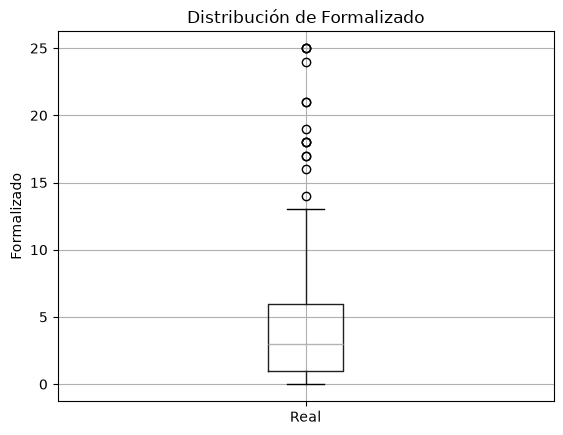

In [57]:
df_funnel[df_funnel["Item"] == "Formalizado"].boxplot(column="Real")

plt.title("Distribución de Formalizado")
plt.ylabel("Formalizado")
plt.show()

In [61]:
ventas = df_funnel[df_funnel["Item"] == "Formalizado"]["Real"]

Q1 = ventas.quantile(0.25)
Q3 = ventas.quantile(0.75)

IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

outliers_ventas = df_funnel[(df_funnel["Item"] == "Formalizado") & ((df_funnel["Real"] < limite_inferior) |(df_funnel["Real"] > limite_superior))]

outliers_ventas

,Mes,Canal,Item,Obj,Real,Acumulado,Obj_al_dia,Cumplimiento
138,Marzo 2025,GAC Angelopolis,Formalizado,26.0,18.0,69.0,26.0,69.0
202,Abril 2025,GAC Angelopolis,Formalizado,26.0,17.0,65.0,26.0,65.0
265,Mayo 2025,GAC Angelopolis,Formalizado,33.0,19.0,58.0,33.0,58.0
328,Junio 2025,GAC Angelopolis,Formalizado,33.0,25.0,76.0,33.0,76.0
391,Julio 2025,GAC Angelopolis,Formalizado,38.0,21.0,55.0,38.0,55.0
526,Septiembre 2025,GAC Angelopolis,Formalizado,38.0,25.0,66.0,38.0,66.0
589,Octubre 2025,GAC Angelopolis,Formalizado,38.0,25.0,66.0,38.0,66.0
652,Noviembre 2025,GAC Angelopolis,Formalizado,38.0,24.0,63.0,38.0,63.0
715,Diciembre 2025,GAC Angelopolis,Formalizado,41.0,14.0,34.0,41.0,34.0
769,Enero 2026,GAC Angelopolis,Formalizado,38.0,21.0,55.0,38.0,55.0


Tratamiento de valores atípicos: Se realizó la identificación de posibles valores atípicos mediante el rango intercuartílico (IQR), considerando cada etapa del funnel por separado debido a las diferencias naturales de escala entre indicadores. Los valores identificados no fueron eliminados, ya que corresponden a observaciones reales de la operación comercial y pueden representar meses o canales con niveles extraordinarios de actividad. Su conservación resulta relevante para analizar el comportamiento real del proceso de conversión.

In [62]:
df_correlacion = df_funnel.pivot_table(index=["Mes", "Canal"], columns="Item", values="Real",aggfunc="sum").reset_index()

In [63]:
df_correlacion.head()

Item,Mes,Canal,Cerrador,Cita efectiva,Cita programada,Formalizado,Leads efectivos,Leads generados,Prueba de manejo,Solicitud de crédito aprobada,Solicitud de crédito generada,Ventas
0,Abril 2025,Digital,NaN,30.0,70.0,2.0,500.0,749.0,17.0,5.0,6.0,5.0
1,Abril 2025,Estrategia de Prospeccion,NaN,1.0,1.0,1.0,27.0,28.0,0.0,2.0,5.0,2.0
2,Abril 2025,GAC Angelopolis,NaN,114.0,174.0,17.0,873.0,1149.0,81.0,35.0,59.0,30.0
3,Abril 2025,Gran Patio,NaN,13.0,15.0,2.0,110.0,113.0,8.0,5.0,9.0,4.0
4,Abril 2025,Otros,NaN,11.0,11.0,0.0,27.0,28.0,1.0,6.0,16.0,2.0


In [64]:
df_correlacion.shape

(132, 12)

In [65]:
df_correlacion.info()

<class 'pandas.DataFrame'>
RangeIndex: 132 entries, 0 to 131
Data columns (total 12 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Mes                            132 non-null    str    
 1   Canal                          132 non-null    str    
 2   Cerrador                       7 non-null      float64
 3   Cita efectiva                  132 non-null    float64
 4   Cita programada                132 non-null    float64
 5   Formalizado                    125 non-null    float64
 6   Leads efectivos                132 non-null    float64
 7   Leads generados                132 non-null    float64
 8   Prueba de manejo               132 non-null    float64
 9   Solicitud de crédito aprobada  132 non-null    float64
 10  Solicitud de crédito generada  132 non-null    float64
 11  Ventas                         132 non-null    float64
dtypes: float64(10), str(2)
memory usage: 12.5 KB


In [66]:
meses = {"Enero 2025": 1, "Febrero 2025": 2, "Marzo 2025": 3, "Abril 2025": 4, "Mayo 2025": 5,
"Junio 2025": 6, "Julio 2025": 7, "Agosto 2025": 8, "Septiembre 2025": 9, "Octubre 2025": 10,
"Noviembre 2025": 11, "Diciembre 2025": 12, "Enero 2026": 13, "Febrero 2026": 14, "Marzo 2026": 15,
"Abril 2026": 16, "Mayo 2026": 17, "Junio 2026": 18}

In [67]:
df_funnel["Mes_num"] = df_funnel["Mes"].map(meses)

In [68]:
df_funnel[["Mes", "Mes_num"]].drop_duplicates()

,Mes,Mes_num
0,Enero 2025,1
65,Febrero 2025,2
130,Marzo 2025,3
194,Abril 2025,4
257,Mayo 2025,5
320,Junio 2025,6
383,Julio 2025,7
446,Agosto 2025,8
518,Septiembre 2025,9
581,Octubre 2025,10


In [69]:
df_funnel.info()

<class 'pandas.DataFrame'>
RangeIndex: 1201 entries, 0 to 1200
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Mes           1201 non-null   str    
 1   Canal         1201 non-null   str    
 2   Item          1201 non-null   str    
 3   Obj           1191 non-null   float64
 4   Real          1200 non-null   float64
 5   Acumulado     1192 non-null   float64
 6   Obj_al_dia    1190 non-null   float64
 7   Cumplimiento  1192 non-null   float64
 8   Mes_num       1201 non-null   int64  
dtypes: float64(5), int64(1), str(3)
memory usage: 84.6 KB


In [70]:
duplicados = df_funnel.duplicated(subset=["Mes_num", "Canal", "Item"], keep=False)

df_funnel[duplicados][["Mes", "Mes_num", "Canal", "Item", "Real"]]

,Mes,Mes_num,Canal,Item,Real
18,Enero 2025,1,Piso,Ventas,10.0
27,Enero 2025,1,Piso,Ventas,10.0
55,Enero 2025,1,Plaza Moraledas,Ventas,0.0
64,Enero 2025,1,Plaza Moraledas,Ventas,0.0
83,Febrero 2025,2,Piso,Ventas,11.0
92,Febrero 2025,2,Piso,Ventas,11.0
93,Febrero 2025,2,Digital,Ventas,4.0
102,Febrero 2025,2,Digital,Ventas,4.0
166,Marzo 2025,3,Gran Patio,Ventas,1.0
175,Marzo 2025,3,Gran Patio,Ventas,1.0


In [72]:
duplicados.sum()

np.int64(26)

In [73]:
df_corr_base = df_funnel.drop_duplicates(subset=["Mes_num", "Canal", "Item", "Real"]).copy()

In [75]:
df_correlacion = df_corr_base.pivot_table(index=["Mes_num", "Canal"],columns="Item",values="Real",aggfunc="sum").reset_index()

In [76]:
df_correlacion.head()

Item,Mes_num,Canal,Cerrador,Cita efectiva,Cita programada,Formalizado,Leads efectivos,Leads generados,Prueba de manejo,Solicitud de crédito aprobada,Solicitud de crédito generada,Ventas
0,1,Digital,7.0,37.0,74.0,NaN,465.0,760.0,22.0,6.0,21.0,9.0
1,1,GAC Angelopolis,19.0,109.0,189.0,NaN,710.0,1029.0,86.0,29.0,82.0,26.0
2,1,Galerias Tlaxcala,2.0,5.0,9.0,NaN,43.0,46.0,9.0,3.0,9.0,3.0
3,1,Otros,1.0,3.0,18.0,NaN,32.0,37.0,7.0,2.0,6.0,2.0
4,1,Piso,7.0,36.0,47.0,NaN,71.0,76.0,34.0,13.0,34.0,10.0


In [77]:
df_correlacion.info()

<class 'pandas.DataFrame'>
RangeIndex: 132 entries, 0 to 131
Data columns (total 12 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Mes_num                        132 non-null    int64  
 1   Canal                          132 non-null    str    
 2   Cerrador                       7 non-null      float64
 3   Cita efectiva                  132 non-null    float64
 4   Cita programada                132 non-null    float64
 5   Formalizado                    125 non-null    float64
 6   Leads efectivos                132 non-null    float64
 7   Leads generados                132 non-null    float64
 8   Prueba de manejo               132 non-null    float64
 9   Solicitud de crédito aprobada  132 non-null    float64
 10  Solicitud de crédito generada  132 non-null    float64
 11  Ventas                         132 non-null    float64
dtypes: float64(10), int64(1), str(1)
memory usage: 12.5 KB


In [78]:
df_correlacion.columns

Index(['Mes_num', 'Canal', 'Cerrador', 'Cita efectiva', 'Cita programada',
       'Formalizado', 'Leads efectivos', 'Leads generados', 'Prueba de manejo',
       'Solicitud de crédito aprobada', 'Solicitud de crédito generada',
       'Ventas'],
      dtype='str', name='Item')

In [79]:
df_correlacion[(df_correlacion["Mes_num"] == 18) & (df_correlacion["Canal"] == "Plaza Pachuca")]

Item,Mes_num,Canal,Cerrador,Cita efectiva,Cita programada,Formalizado,Leads efectivos,Leads generados,Prueba de manejo,Solicitud de crédito aprobada,Solicitud de crédito generada,Ventas
130,18,Plaza Pachuca,NaN,13.0,16.0,0.0,72.0,72.0,6.0,3.0,6.0,4.0


In [80]:
variables_numericas = df_correlacion.select_dtypes(include="number")

variables_numericas.head()

Item,Mes_num,Cerrador,Cita efectiva,Cita programada,Formalizado,Leads efectivos,Leads generados,Prueba de manejo,Solicitud de crédito aprobada,Solicitud de crédito generada,Ventas
0,1,7.0,37.0,74.0,NaN,465.0,760.0,22.0,6.0,21.0,9.0
1,1,19.0,109.0,189.0,NaN,710.0,1029.0,86.0,29.0,82.0,26.0
2,1,2.0,5.0,9.0,NaN,43.0,46.0,9.0,3.0,9.0,3.0
3,1,1.0,3.0,18.0,NaN,32.0,37.0,7.0,2.0,6.0,2.0
4,1,7.0,36.0,47.0,NaN,71.0,76.0,34.0,13.0,34.0,10.0


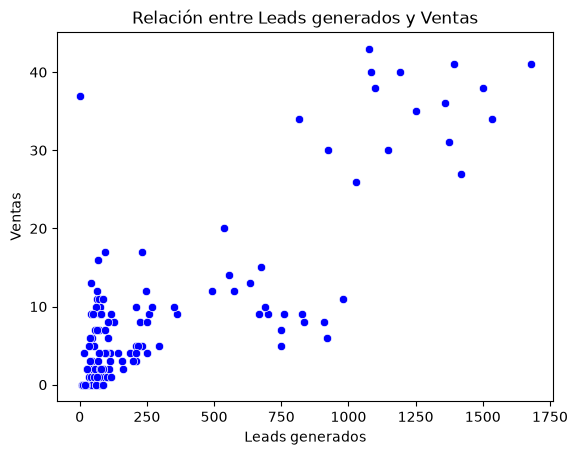

In [ ]:
#Imprimimos el scatter plot entre la variable dependiente e independiente 
sns.scatterplot( x='Leads generados', y='Ventas', color="blue", data=df_correlacion)

plt.title("Relación entre Leads generados y Ventas")
plt.show()

In [ ]:
**Modelo matemático: y= 2.0325063(5.640) + 5.857776154826299**


In [ ]:
#Declaramos las variables dependientes e independientes para la regresión lineal

Vars_Indep = df_correlacion[['Leads generados']]
Var_Dep = df_correlacion['Ventas']

In [84]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

In [ ]:
#Ajustamos el modelo con las variables antes declaradas
model.fit(X=Vars_Indep, y=Var_Dep)

In [ ]:
model.fit( X=Vars_Indep, y=Var_Dep)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[0.02]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['Leads generados']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.607
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [86]:
model.__dict__

{'fit_intercept': True,
 'copy_X': True,
 'tol': 1e-06,
 'n_jobs': None,
 'positive': False,
 'feature_names_in_': array(['Leads generados'], dtype=object),
 'n_features_in_': 1,
 'coef_': array([0.02137229]),
 'rank_': np.int64(1),
 'singular_': array([4780.44882751]),
 'intercept_': np.float64(2.6066426380418752)}

In [ ]:
#Evaluamos la eficiencia del modelo obtenido por medio del coeficiente R Determinación
model.score(Vars_Indep, Var_Dep)

0.6547721616252343

In [ ]:
#Predecimos los valores de total de ventas con base en los leads generados
y_pred = model.predict(X=df_correlacion[['Leads generados']])
y_pred

array([18.84958587, 24.59873288,  3.58976815,  3.39741751,  4.23093696,
        4.95759495,  2.88448246,  7.09482432,  4.48740449, 14.08356437,
        4.1027032 ,  2.92722704,  3.97446944,  4.53014907, 13.10043886,
        3.35467292, 22.37601433,  4.95759495,  3.61114044,  4.31642614,
        6.06895422, 18.61449064,  3.20506686, 27.16340813,  5.02171183,
        3.20506686,  3.52565127,  6.62463386, 10.32204067,  4.33779843,
       20.02506202,  5.04308412,  3.39741751,  3.99584173,  5.96209275,
       14.91708382,  3.46153439, 25.75283674,  4.65838284,  3.73937421,
        3.86760797,  8.14206671, 17.54587595,  3.78211879, 31.63021751,
        5.62013605,  3.33330062,  3.95309714, 10.10831773,  2.75624869,
       20.28152955,  3.61114044, 32.93392743,  4.7866166 ,  4.1027032 ,
        4.12407549,  8.91146929, 17.05431319,  2.99134393, 26.11616573,
        4.03858632,  3.37604521,  3.84623567,  7.8428546 , 17.31078072,
        3.54702356, 28.08241676,  3.80349109,  3.97446944,  4.14

In [ ]:
#Insertamos la columna de predicciones en el DataFrame
df_correlacion['Predicciones'] = y_pred

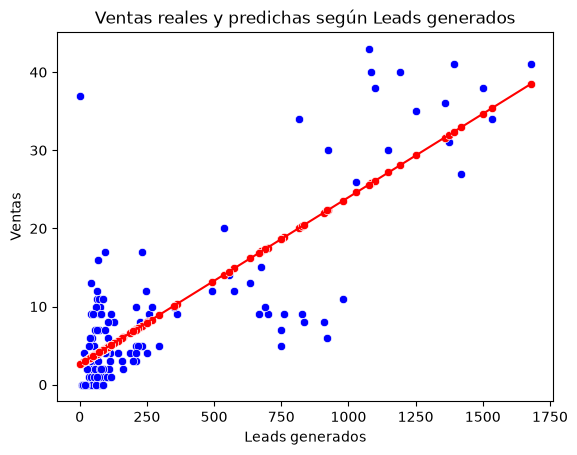

In [ ]:
#Visualizamos la gráfica comparativa entre el total real y el total predecido
sns.scatterplot(x='Leads generados', y='Ventas', color="blue",data=df_correlacion)
sns.scatterplot(x='Leads generados', y='Predicciones', color="red", data=df_correlacion)
sns.lineplot(x='Leads generados', y='Predicciones', color="red", data=df_correlacion)

plt.title("Ventas reales y predichas según Leads generados")
plt.show()



In [ ]:
#Corroboramos cual es el coeficiente de Determinación de nuestro modelo
coef_Deter = model.score( X=Vars_Indep, y=Var_Dep)
coef_Deter

0.6547721616252343

In [ ]:
#Corroboramos cual es el coeficiente de Correlación de nuestro modelo
coef_Correl = np.sqrt(coef_Deter)
coef_Correl

np.float64(0.8091799315512183)

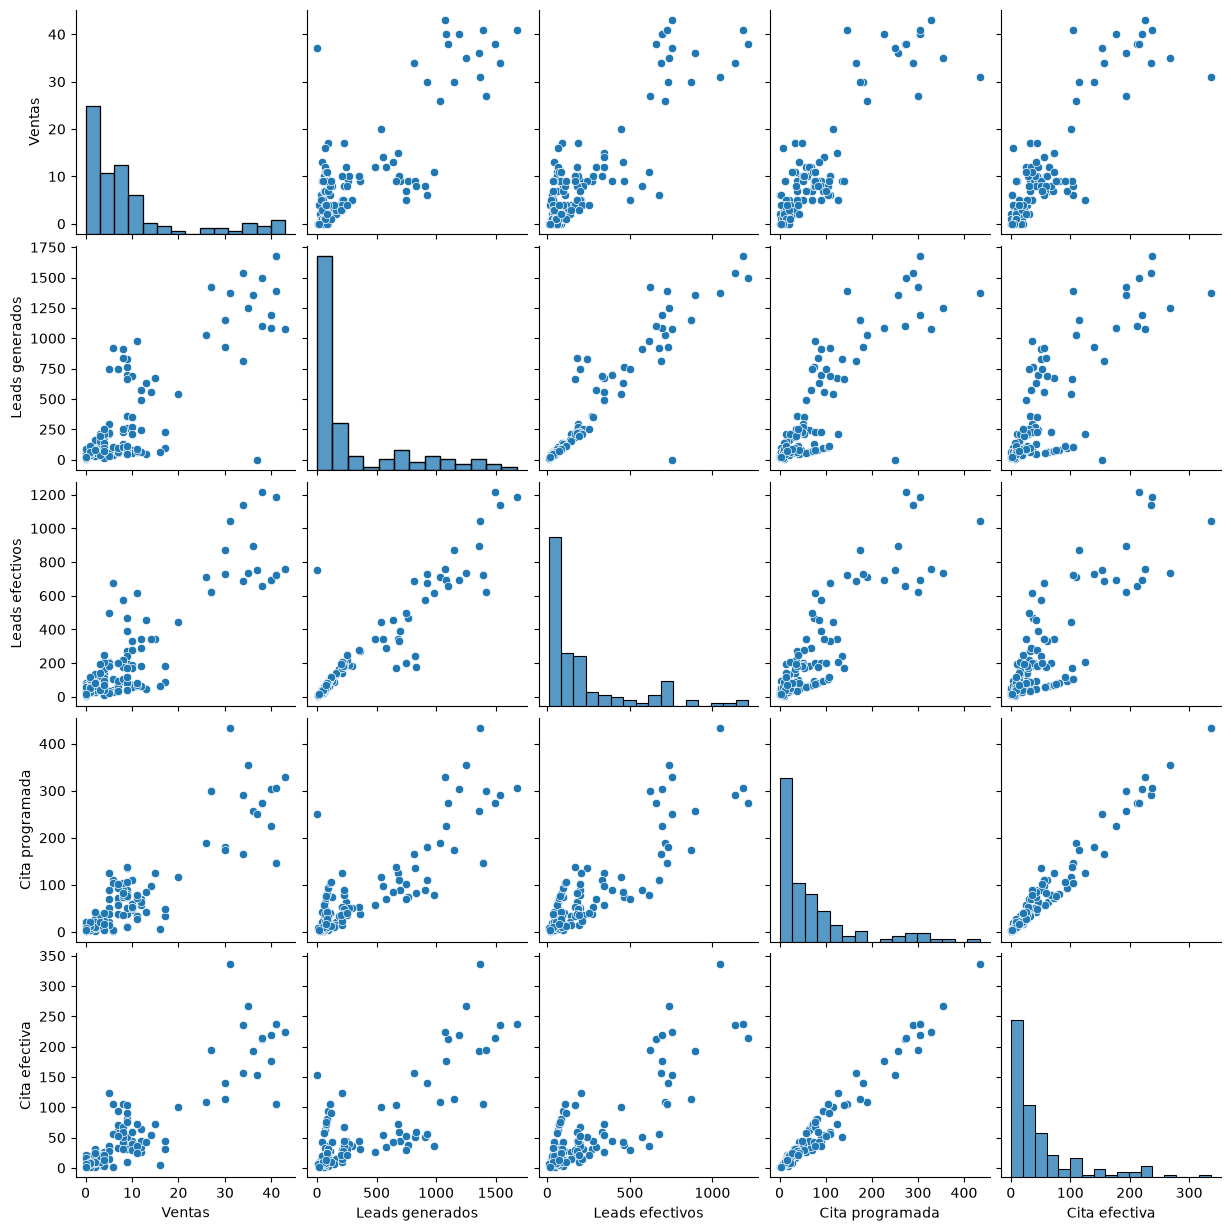

In [ ]:
#Graficamos todas las dispersiones entre todas las variables
sns.pairplot(df_numerico[["Ventas","Leads generados", "Leads efectivos", "Cita programada", "Cita efectiva"]])
plt.show()

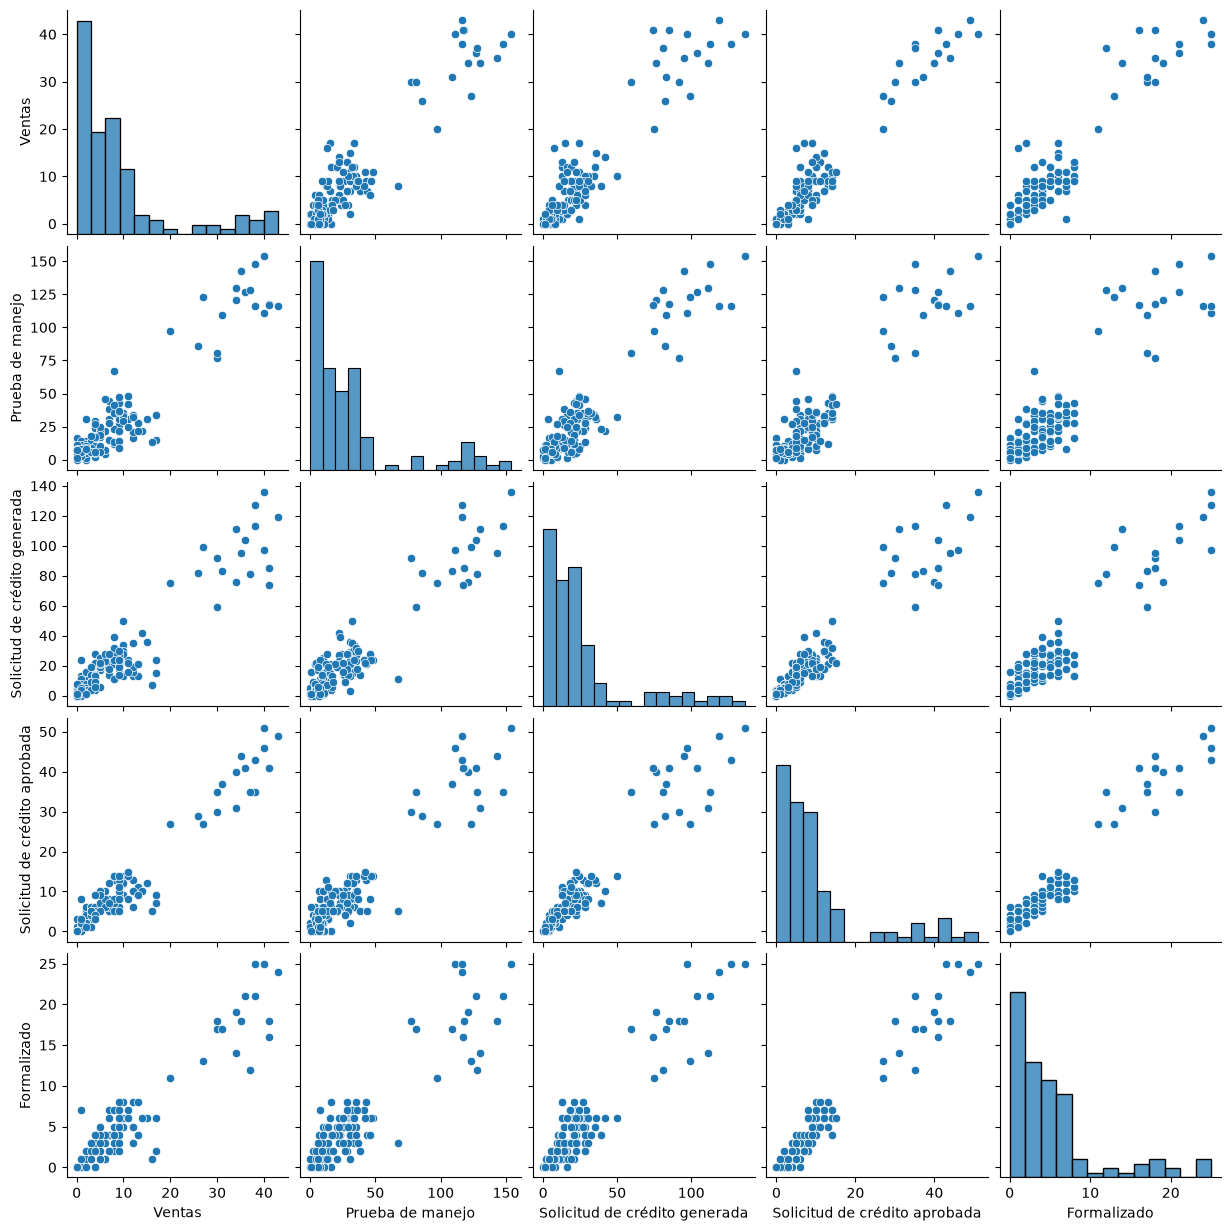

In [104]:
sns.pairplot(df_numerico[["Ventas","Prueba de manejo","Solicitud de crédito generada","Solicitud de crédito aprobada","Formalizado"]])

plt.show()

In [115]:
Corr_Factors = df_numerico.corr()

Corr_Factors

Item,Mes_num,Cita efectiva,Cita programada,Formalizado,Leads efectivos,Leads generados,Prueba de manejo,Solicitud de crédito aprobada,Solicitud de crédito generada,Ventas
Item,,,,,,,,,,
Mes_num,1.000000,0.097644,0.100008,-0.066097,0.044223,0.039013,0.050478,0.008907,-0.019517,0.039430
Cita efectiva,0.097644,1.000000,0.979408,0.863738,0.834841,0.794976,0.919774,0.884320,0.894914,0.875380
Cita programada,0.100008,0.979408,1.000000,0.861457,0.878142,0.852480,0.914668,0.890034,0.909944,0.885594
Formalizado,-0.066097,0.863738,0.861457,1.000000,0.820851,0.781174,0.912785,0.972175,0.938315,0.941962
Leads efectivos,0.044223,0.834841,0.878142,0.820851,1.000000,0.930698,0.847532,0.836163,0.851416,0.864885
Leads generados,0.039013,0.794976,0.852480,0.781174,0.930698,1.000000,0.791572,0.791495,0.824942,0.809180
Prueba de manejo,0.050478,0.919774,0.914668,0.912785,0.847532,0.791572,1.000000,0.940141,0.935455,0.936229
Solicitud de crédito aprobada,0.008907,0.884320,0.890034,0.972175,0.836163,0.791495,0.940141,1.000000,0.950762,0.964393
Solicitud de crédito generada,-0.019517,0.894914,0.909944,0.938315,0.851416,0.824942,0.935455,0.950762,1.000000,0.934465


In [97]:
Corr_Factors1 = abs(Corr_Factors)

Corr_Factors1

Item,Mes_num,Cerrador,Cita efectiva,Cita programada,Formalizado,Leads efectivos,Leads generados,Prueba de manejo,Solicitud de crédito aprobada,Solicitud de crédito generada,Ventas,Predicciones
Item,,,,,,,,,,,,
Mes_num,1.000000,NaN,0.097644,0.100008,0.066097,0.044223,0.039013,0.050478,0.008907,0.019517,0.039430,0.039013
Cerrador,NaN,1.000000,0.979544,0.977336,NaN,0.906287,0.877256,0.987345,0.973288,0.988224,0.998445,0.877256
Cita efectiva,0.097644,0.979544,1.000000,0.979408,0.863738,0.834841,0.794976,0.919774,0.884320,0.894914,0.875380,0.794976
Cita programada,0.100008,0.977336,0.979408,1.000000,0.861457,0.878142,0.852480,0.914668,0.890034,0.909944,0.885594,0.852480
Formalizado,0.066097,NaN,0.863738,0.861457,1.000000,0.820851,0.781174,0.912785,0.972175,0.938315,0.941962,0.781174
Leads efectivos,0.044223,0.906287,0.834841,0.878142,0.820851,1.000000,0.930698,0.847532,0.836163,0.851416,0.864885,0.930698
Leads generados,0.039013,0.877256,0.794976,0.852480,0.781174,0.930698,1.000000,0.791572,0.791495,0.824942,0.809180,1.000000
Prueba de manejo,0.050478,0.987345,0.919774,0.914668,0.912785,0.847532,0.791572,1.000000,0.940141,0.935455,0.936229,0.791572
Solicitud de crédito aprobada,0.008907,0.973288,0.884320,0.890034,0.972175,0.836163,0.791495,0.940141,1.000000,0.950762,0.964393,0.791495


In [ ]:
# Seleccionamos únicamente las variables numéricas
# y eliminamos Predicciones del análisis de correlación

df_numerico = df_correlacion.select_dtypes(include="number").drop(columns=["Predicciones", "Cerrador"],errors="ignore")

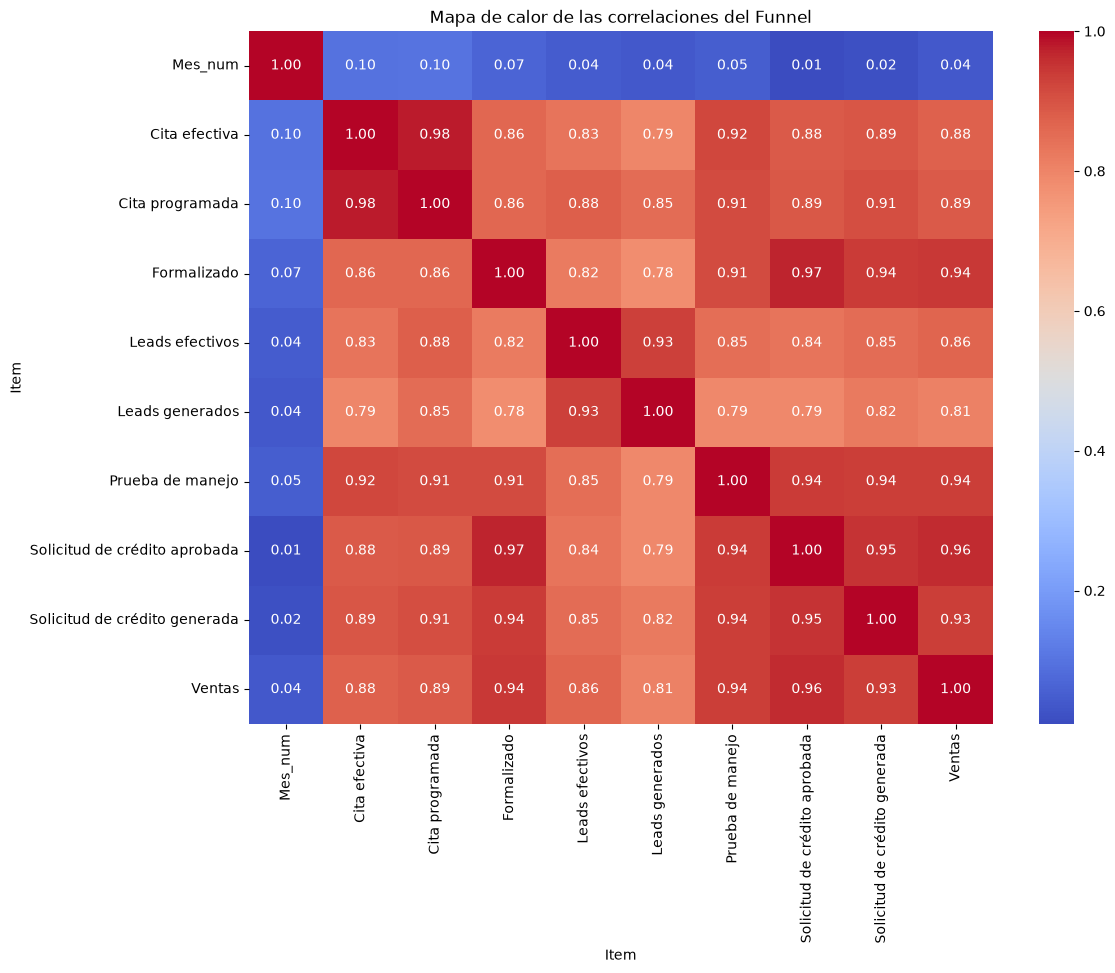

In [120]:
# Graficamos el mapa de calor de los coeficientes de correlación
plt.figure(figsize=(12, 9))

Heat_Map = sns.heatmap( Corr_Factors1, cmap="coolwarm", annot=True, fmt=".2f")

plt.title("Mapa de calor de las correlaciones del Funnel")

plt.show()

In [ ]:
correlaciones_ventas = (Corr_Factors1["Ventas"].sort_values(ascending=False))

correlaciones_ventas

Item
Ventas                           1.000000
Solicitud de crédito aprobada    0.964393
Formalizado                      0.941962
Prueba de manejo                 0.936229
Solicitud de crédito generada    0.934465
Cita programada                  0.885594
Cita efectiva                    0.875380
Leads efectivos                  0.864885
Leads generados                  0.809180
Mes_num                          0.039430
Name: Ventas, dtype: float64

El análisis de correlación muestra relaciones positivas entre las distintas etapas del funnel y las ventas. Aunque los leads generados presentan una correlación alta con las ventas (0.81), las relaciones son mayores en etapas posteriores, como la prueba de manejo (0.94), la formalización (0.94) y las solicitudes de crédito aprobadas (0.96). Esto sugiere que el volumen de leads es relevante, pero el avance y seguimiento de los prospectos a través del proceso comercial podría estar más estrechamente relacionado con la venta final.

In [117]:
print("Intercepto:", model.intercept_)
print("Coeficiente:", model.coef_[0])
print("R²:", coef_Deter)
print("Correlación:", coef_Correl)

Intercepto: 2.6066426380418752
Coeficiente: 0.02137229372262266
R²: 0.6547721616252343
Correlación: 0.8091799315512183
